# Introduction

This notebook introduces the main concepts leading up to retrograde motion of the planets.

The actual lab exercise will start right after the final part of this notebook, which will introduce the "data", but it will be on a separate notebook. 

# Contents

- [The stars above Lehman College through the night](#through_the_night)
- [How the sky changes across the year](#through_the_year)
- [Motions of Stars and Planets](#stars_vs_planets)
- [The position of Mars](#mars)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection

import skyfield
from skyfield.api import Topos, Star, load, wgs84
from skyfield.almanac import find_discrete, risings_and_settings
from skyfield.projections import build_stereographic_projection
from skyfield import almanac
from skyfield.data import hipparcos, stellarium

In [2]:
eph = load('de421.bsp')

# The Hipparcos mission provides our star catalog.
with load.open(hipparcos.URL) as f:
    stars = hipparcos.load_dataframe(f)

# And the constellation outlines come from Stellarium.
# We make a list of the stars at which each edge stars, and the star at which each edge ends.
url = ('https://raw.githubusercontent.com/Stellarium/stellarium/'
       'eb47095a9282cf6b981f6e37fe1ea3a3ae0fd167'
       '/skycultures/modern_st/constellationship.fab')

with load.open(url) as f:
    constellations = stellarium.parse_constellations(f)

<a id='through_the_night'></a>

# The stars above Lehman College through the night

An animation of how the sky moves above Lehman College from sunset to dawn.

The point of reference will be a photograph of the "skyline" of the Bronx around Lehman college with the dark silhouettes of the surrounding buildings (or our telescope's dome, Gillet Hall, etc).

The students could control the date and how frequent the animation frames occur.

Eventually, we could replace this with photographs of the sky taken with our own telescope.

<a id='through_the_year'></a>

# How the sky changes across the year

Exactly the same animation as above, but now the frames are taken at the same time, e.g. midnight, over a year.

The students can control the duration of this animation and how frequently the frames are drawn (although it is periodic over a year)

<a id='stars_vs_planets'></a>

# Motions of Stars and Planets

The students will choose a star from a catalogue of named and well-known stars (e.g. Sirius, Betelgeuse, Aldebaran, etc). The position of this star and its distances to all the other stars in this catalogue will be indicated on the animation from the previous step. This will demosntrate that the stars do not move with respect to each other.

Then, the students will choose a planet and the same animation will be repeated. The list of planets will be optimized to ensure that they are on the sky for the selected dates. This will demonstrate that the planets are moving on the sky with respect to the stars.

<a id='mars'></a>

# The position of Mars

Define various moments in local time (time at a specific location on Earth) and get the Mars ephemerides in the equatorial reference frame (RA and DEC).

In [4]:
eph = load('de421.bsp')
earth, sun, mars = eph['earth'], eph['sun'], eph['mars']

# I need to replace this with New York
observer = wgs84.latlon(+40.0, 0.0)

ts = load.timescale()
start, end = ts.utc(2024, 9, 1), ts.utc(2025, 6, 31)

# I need to replace this with midnight in New York
f = almanac.sunrise_sunset(eph, observer)
t_tmp, y = almanac.find_discrete(start, end, f)
sunsets = (y == 0)
t = t_tmp[sunsets]

ra, dec, z = (earth + observer).at(t).observe(mars).radec()
mars_ra, mars_dec = ra.degrees, dec.degrees

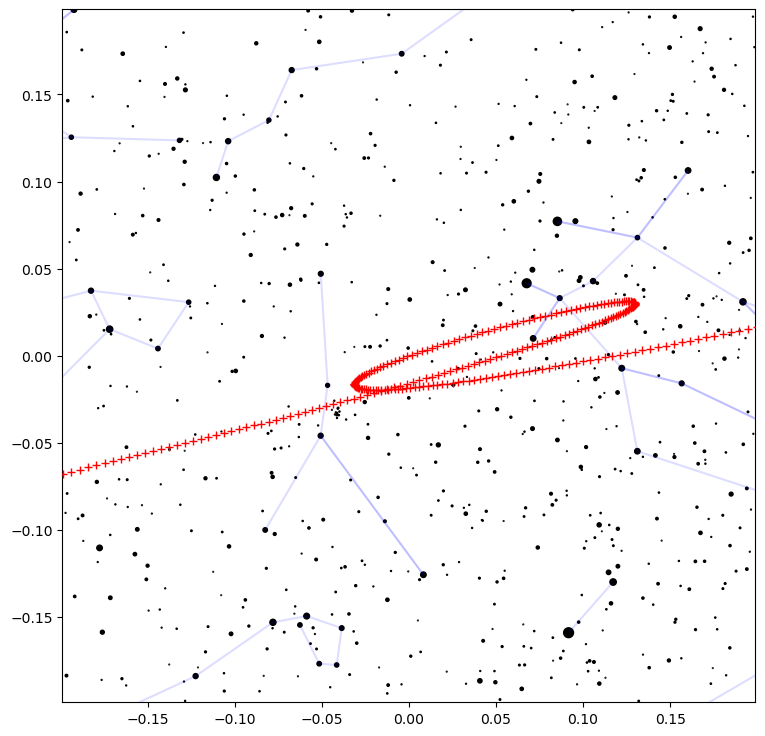

In [5]:
edges = [edge for name, edges in constellations for edge in edges]
edges_star1 = [star1 for star1, star2 in edges]
edges_star2 = [star2 for star1, star2 in edges]




# We will center the chart on the comet's middle position.

t0 = ts.utc(2024,12,31)
center = earth.at(t0).observe(mars)
projection = build_stereographic_projection(center)
field_of_view_degrees = 45.0
limiting_magnitude = 7.0


# Now that we have constructed our projection, compute the x and y
# coordinates that each star and the comet will have on the plot.

star_positions = earth.at(t0).observe(Star.from_dataframe(stars))
stars['x'], stars['y'] = projection(star_positions)

mars_x, mars_y = projection(earth.at(t).observe(mars))


# Create a True/False mask marking the stars bright enough to be
# included in our plot.  And go ahead and compute how large their
# markers will be on the plot.

bright_stars = (stars.magnitude <= limiting_magnitude)
magnitude = stars['magnitude'][bright_stars]
marker_size = (0.5 + limiting_magnitude - magnitude) ** 2.0

# The constellation lines will each begin at the x,y of one star and end
# at the x,y of another.  We have to "rollaxis" the resulting coordinate
# array into the shape that matplotlib expects.

xy1 = stars[['x', 'y']].loc[edges_star1].values
xy2 = stars[['x', 'y']].loc[edges_star2].values
lines_xy = np.rollaxis(np.array([xy1, xy2]), 1)

# Time to build the figure!
fig, ax = plt.subplots(figsize=[9, 9])

# Draw the constellation lines.
ax.add_collection(LineCollection(lines_xy, colors='#00f2'))

# Draw the stars.
ax.scatter(stars['x'][bright_stars], stars['y'][bright_stars], s=marker_size, color='k')

# Draw Mars' positions, and label them with dates.
mars_color = '#f00'
offset = 0.002

ax.plot(mars_x, mars_y, '+', c=mars_color, zorder=3)

#for xi, yi, tstr in zip(mars_x, mars_y, t.utc_strftime('%m/%d')):
#    tstr = tstr.lstrip('0')
#    text = ax.text(xi + offset, yi - offset, tstr, color=mars_color, ha='left', va='top', fontsize=9, weight='bold', zorder=-1)
#    text.set_alpha(0.5)


# Finally, title the plot and set some final parameters.
angle = np.pi - field_of_view_degrees / 360.0 * np.pi
limit = np.sin(angle) / (1.0 - np.cos(angle))

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
#ax.xaxis.set_visible(False)
#ax.yaxis.set_visible(False)
ax.set_aspect(1.0)

plt.show()